# Autoencoder comparison with a frozen ResNet-18 + 5-NN baseline

This notebook compares three complete autoencoder methods and a frozen ResNet-18 + 5-NN image-level baseline on the same Bottle data split. Every method uses the same seed-17 85/15 split of the official normal-only training set and is evaluated on the same official test set.

The main method-specific design choices are retained. AE-06 uses pixels in `[0, 1]` with a sigmoid decoder, Karim's model uses ImageNet normalization with a tanh decoder, and Benjamin's method uses `[0, 1]` pixels, masked-image training, and a combined SSIM-MSE loss. Benjamin's TensorFlow/Keras implementation is closely reproduced in PyTorch so it can run in this project's existing environment. The three autoencoders receive 256 x 256 images; the pretrained ResNet receives its method-specific 224 x 224 ImageNet representation. The autoencoders and the project-specific 5-NN reference bank fit only normal Bottle training images; the frozen ResNet backbone retains its external ImageNet pretraining. This is therefore a comparison of **complete methods**, not a controlled claim that architecture alone caused a difference.

AUROC and PR-AUC compare score rankings without requiring an operating threshold. Threshold-based metrics use independently calculated 95th-percentile normal-validation thresholds, so the test labels are reserved for final evaluation rather than threshold selection.

In [8]:
from pathlib import Path
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, f1_score,
    precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader
from torchmetrics.functional.image import structural_similarity_index_measure
from torchvision import transforms

from app.pipelines.modelling import MVTecImageDataset, build_mvtec_manifest

SEED = 17
IMAGE_SIZE = 256
BATCH_SIZE = 16
NUM_WORKERS = 2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIN_MEMORY = DEVICE.type == 'cuda'
IMAGE_THRESHOLD_PERCENTILE = 95
PIXEL_THRESHOLD_PERCENTILE = 99

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

project_root = next(
    path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / 'pyproject.toml').is_file()
)
models_dir = project_root / 'models'
models_dir.mkdir(exist_ok=True)
print(f'Using {DEVICE}')

Using cuda


## Shared split

The shared seed-17 split is created once: 85% of the official normal training set is used for fitting and 15% for checkpoint selection and threshold calibration. The same image paths are passed to every method, and the same training seed is used for each trainable autoencoder. The frozen ResNet baseline has no learned training parameters; its 5-NN reference bank uses the same 85% fitting subset. The official test set is never used for training, checkpoint selection, or threshold calibration.

In [9]:
manifest = build_mvtec_manifest(project_root / 'data/raw/mvtec_ad')
normal_pool = manifest.query(
    "product == 'bottle' and split == 'train' and not is_anomaly"
).reset_index(drop=True)
test_frame = manifest.query(
    "product == 'bottle' and split == 'test'"
).reset_index(drop=True)
train_frame, validation_frame = train_test_split(
    normal_pool, test_size=0.15, random_state=SEED
)
train_frame = train_frame.reset_index(drop=True)
validation_frame = validation_frame.reset_index(drop=True)

assert len(train_frame) == 177 and len(validation_frame) == 32
assert set(train_frame.path).isdisjoint(validation_frame.path)
assert set(normal_pool.path).isdisjoint(test_frame.path)
print(f'Train: {len(train_frame)} normal images')
print(f'Validation: {len(validation_frame)} normal images')
print(f'Test: {len(test_frame)} images ({test_frame.is_anomaly.sum()} anomalous)')

Train: 177 normal images
Validation: 32 normal images
Test: 83 images (63 anomalous)


## Autoencoder models and method-specific preprocessing

All three models are trained or loaded from protocol-specific checkpoints created with the shared 85/15 split and seed 17. AE-06 and Karim's architecture receive the same 200-epoch budget and learning-rate schedule, and each retains the checkpoint with the lowest normal-validation MSE. Benjamin's Keras architecture is closely reproduced in PyTorch, including Keras-compatible BatchNorm hyperparameters, and trained with his masking task, SSIM-MSE loss, AdamW, early stopping, and learning-rate reduction. Framework-specific numerical details can still differ. Benjamin's default 64-pixel crop is changed to the common 256 x 256 whole-image representation supported by his fully convolutional model. Results must therefore be described as **Karim's architecture under the team protocol** and **Benjamin's method under the common 256 x 256 Bottle protocol**.

In [10]:
class ConvAutoencoder16(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(128, 128, 4, 2, 1), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Sigmoid(),
        )

    def forward(self, images):
        return self.decoder(self.encoder(images))


class KarimBottleAutoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
        )
        self.flatten = nn.Flatten()
        self.fc_encode = nn.Linear(32 * 32 * 128, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 32 * 32 * 128)
        self.unflatten = nn.Unflatten(1, (128, 32, 32))
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Tanh(),
        )

    def forward(self, images):
        encoded = self.encoder(images)
        latent = self.fc_encode(self.flatten(encoded))
        decoded = self.fc_decode(latent)
        return self.decoder(self.unflatten(decoded))


class BenjaminCAE(nn.Module):
    """PyTorch reproduction of Benjamin's TensorFlow/Keras CAE."""
    def __init__(self, latent_channels=32):
        super().__init__()

        def block(in_channels, out_channels, kernel_size, stride):
            padding = 1
            return [
                nn.Conv2d(
                    in_channels, out_channels, kernel_size, stride, padding,
                    bias=False,
                ),
                # Keras defaults: epsilon=1e-3 and running-stat update=0.01.
                nn.BatchNorm2d(out_channels, eps=1e-3, momentum=0.01),
                nn.ELU(),
            ]

        self.encoder = nn.Sequential(
            *block(3, 32, 4, 2),
            *block(32, 64, 4, 2),
            *block(64, 128, 4, 2),
            *block(128, 256, 4, 2),
            nn.Conv2d(256, latent_channels, 3, 1, 1, bias=False),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_channels, 256, 3, 1, 1, bias=False),
            nn.BatchNorm2d(256, eps=1e-3, momentum=0.01), nn.ELU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128, eps=1e-3, momentum=0.01), nn.ELU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64, eps=1e-3, momentum=0.01), nn.ELU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
            nn.BatchNorm2d(32, eps=1e-3, momentum=0.01), nn.ELU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Sigmoid(),
        )

    def forward(self, images):
        return self.decoder(self.encoder(images))


ae06_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), transforms.ToTensor(),
])
karim_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def make_loaders(transform, training_seed):
    train_dataset = MVTecImageDataset(train_frame, transform)
    validation_dataset = MVTecImageDataset(validation_frame, transform)
    test_dataset = MVTecImageDataset(test_frame, transform)
    generator = torch.Generator().manual_seed(training_seed)
    common = dict(num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    return (
        DataLoader(train_dataset, BATCH_SIZE, shuffle=True, generator=generator, **common),
        DataLoader(validation_dataset, BATCH_SIZE, shuffle=False, **common),
        DataLoader(test_dataset, BATCH_SIZE, shuffle=False, **common),
    )

ae06_train_loader, ae06_validation_loader, ae06_test_loader = make_loaders(
    ae06_transform, SEED
)
karim_train_loader, karim_validation_loader, karim_test_loader = make_loaders(
    karim_transform, SEED
)
benjamin_train_loader, benjamin_validation_loader, benjamin_test_loader = make_loaders(
    ae06_transform, SEED
)

In [11]:
COMMON_MAX_EPOCHS = 200
COMMON_INITIAL_LEARNING_RATE = 1e-3
COMMON_LR_CHANGE_EPOCH = 150
COMMON_REFINEMENT_LEARNING_RATE = 1e-4
RETRAIN_AE06 = False
RETRAIN_KARIM = False


def train_or_load_mse_model(
    model, model_name, train_loader, validation_loader, checkpoint_path,
    config, retrain=False,
):
    if checkpoint_path.exists() and not retrain:
        checkpoint = torch.load(
            checkpoint_path, map_location=DEVICE, weights_only=False
        )
        if checkpoint.get('metadata', {}).get('config') != config:
            raise ValueError(
                f'{model_name} checkpoint settings differ from the team protocol. '
                'Set its RETRAIN flag to True only if replacement is intended.'
            )
        model.load_state_dict(checkpoint['model_state_dict'])
        history = checkpoint['metadata']['history']
        best_epoch = checkpoint['metadata']['best_epoch']
        print(f'Loaded {model_name} checkpoint selected at epoch {best_epoch}')
        model.eval()
        return history, best_epoch

    optimizer = torch.optim.Adam(model.parameters(), lr=COMMON_INITIAL_LEARNING_RATE)
    criterion = nn.MSELoss()
    history = {'train_loss': [], 'validation_loss': []}
    best_validation_loss = float('inf')
    best_state = None
    best_epoch = 0
    for epoch in range(1, COMMON_MAX_EPOCHS + 1):
        if epoch == COMMON_LR_CHANGE_EPOCH + 1:
            for parameter_group in optimizer.param_groups:
                parameter_group['lr'] = COMMON_REFINEMENT_LEARNING_RATE
        model.train()
        train_total = 0.0
        for images, _, _ in train_loader:
            images = images.to(DEVICE, non_blocking=PIN_MEMORY)
            optimizer.zero_grad()
            loss = criterion(model(images), images)
            loss.backward()
            optimizer.step()
            train_total += loss.item() * len(images)

        model.eval()
        validation_total = 0.0
        with torch.inference_mode():
            for images, _, _ in validation_loader:
                images = images.to(DEVICE, non_blocking=PIN_MEMORY)
                validation_total += criterion(model(images), images).item() * len(images)
        train_loss = train_total / len(train_loader.dataset)
        validation_loss = validation_total / len(validation_loader.dataset)
        history['train_loss'].append(train_loss)
        history['validation_loss'].append(validation_loss)
        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
        if epoch == 1 or epoch % 10 == 0:
            print(
                f'{model_name} epoch {epoch:03d}: train={train_loss:.6f}, '
                f'validation={validation_loss:.6f}, '
                f"lr={optimizer.param_groups[0]['lr']:.0e}"
            )

    model.load_state_dict(best_state)
    torch.save({
        'model_state_dict': model.state_dict(),
        'metadata': {
            'experiment': model_name, 'config': config,
            'best_epoch': best_epoch, 'history': history,
        },
    }, checkpoint_path)
    print(f'Saved {checkpoint_path}')
    model.eval()
    return history, best_epoch


common_training_config = {
    'seed': SEED, 'validation_fraction': 0.15, 'batch_size': BATCH_SIZE,
    'train_paths': train_frame.path.tolist(),
    'validation_paths': validation_frame.path.tolist(),
    'max_epochs': COMMON_MAX_EPOCHS,
    'initial_learning_rate': COMMON_INITIAL_LEARNING_RATE,
    'learning_rate_change_epoch': COMMON_LR_CHANGE_EPOCH,
    'refinement_learning_rate': COMMON_REFINEMENT_LEARNING_RATE,
}

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
ae06 = ConvAutoencoder16().to(DEVICE)
ae06_config = {**common_training_config, 'architecture': 'ConvAutoencoder16'}
ae06_history, ae06_best_epoch = train_or_load_mse_model(
    ae06, 'AE-06 under team protocol', ae06_train_loader,
    ae06_validation_loader, models_dir / 'ae06_team_protocol_85_15.pt',
    ae06_config, RETRAIN_AE06,
)

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
karim = KarimBottleAutoencoder(latent_dim=128).to(DEVICE)
karim_config = {
    **common_training_config, 'architecture': 'KarimBottleAutoencoder',
    'latent_dim': 128,
}
karim_history, karim_best_epoch = train_or_load_mse_model(
    karim, 'Karim architecture under team protocol', karim_train_loader,
    karim_validation_loader, models_dir / 'karim_team_protocol_85_15.pt',
    karim_config, RETRAIN_KARIM,
)

Loaded AE-06 under team protocol checkpoint selected at epoch 199
Loaded Karim architecture under team protocol checkpoint selected at epoch 200


## Benjamin's masked SSIM-MSE method

Benjamin's source implementation defaults to 64-pixel crops. Here the same fully convolutional architecture operates on the common 256 x 256 whole-image inputs so that every test score still represents one Bottle image. During training, 25% of 16 x 16 patches are zeroed and the clean image remains the target. Validation and test inputs are never masked. Checkpoint selection observes only the 32 normal validation images; anomalous test images are not passed into the training function.

The PyTorch SSIM implementation uses an 11 x 11 Gaussian window, sigma 1.5, and a `[0, 1]` data range, matching the principal settings of `tf.image.ssim`. TorchMetrics and TensorFlow handle image boundaries differently, and optimizer and initialization details can also produce numerical differences. This is therefore labelled a close reproduction of Benjamin's method rather than his original trained checkpoint.

In [12]:
BENJAMIN_MAX_EPOCHS = 200
BENJAMIN_LEARNING_RATE = 1e-3
BENJAMIN_WEIGHT_DECAY = 1e-4
BENJAMIN_MASK_RATIO = 0.25
BENJAMIN_PATCH_SIZE = 16
BENJAMIN_SSIM_WEIGHT = 0.84
BENJAMIN_EARLY_STOPPING_PATIENCE = 20
BENJAMIN_LR_PATIENCE = 5
BENJAMIN_LR_FACTOR = 0.5
RETRAIN_BENJAMIN = False


def apply_patch_masking(images, mask_ratio, patch_size, generator):
    masked = images.clone()
    patches_high = images.shape[-2] // patch_size
    patches_wide = images.shape[-1] // patch_size
    total_patches = patches_high * patches_wide
    masked_count = max(1, int(total_patches * mask_ratio))
    for image_index in range(len(images)):
        patch_indices = torch.randperm(
            total_patches, generator=generator
        )[:masked_count]
        for patch_index in patch_indices.tolist():
            row = (patch_index // patches_wide) * patch_size
            column = (patch_index % patches_wide) * patch_size
            masked[
                image_index, :, row:row + patch_size, column:column + patch_size
            ] = 0.0
    return masked


def benjamin_loss(targets, reconstructions):
    ssim = structural_similarity_index_measure(
        reconstructions, targets,
        gaussian_kernel=True, sigma=1.5, kernel_size=11, data_range=1.0,
    )
    mse = (targets - reconstructions).square().mean()
    return BENJAMIN_SSIM_WEIGHT * (1.0 - ssim) + (
        1.0 - BENJAMIN_SSIM_WEIGHT
    ) * mse


benjamin_config = {
    'architecture': 'BenjaminCAE', 'image_size': IMAGE_SIZE,
    'latent_channels': 32, 'seed': SEED, 'validation_fraction': 0.15,
    'batch_size': BATCH_SIZE,
    'train_paths': train_frame.path.tolist(),
    'validation_paths': validation_frame.path.tolist(),
    'max_epochs': BENJAMIN_MAX_EPOCHS, 'learning_rate': BENJAMIN_LEARNING_RATE,
    'weight_decay': BENJAMIN_WEIGHT_DECAY, 'mask_ratio': BENJAMIN_MASK_RATIO,
    'patch_size': BENJAMIN_PATCH_SIZE, 'ssim_weight': BENJAMIN_SSIM_WEIGHT,
    'early_stopping_patience': BENJAMIN_EARLY_STOPPING_PATIENCE,
    'lr_patience': BENJAMIN_LR_PATIENCE, 'lr_factor': BENJAMIN_LR_FACTOR,
}
benjamin_checkpoint_path = models_dir / 'benjamin_team_protocol_85_15.pt'
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
benjamin = BenjaminCAE(latent_channels=32).to(DEVICE)

if benjamin_checkpoint_path.exists() and not RETRAIN_BENJAMIN:
    checkpoint = torch.load(
        benjamin_checkpoint_path, map_location=DEVICE, weights_only=False
    )
    if checkpoint.get('metadata', {}).get('config') != benjamin_config:
        raise ValueError(
            'Benjamin checkpoint settings differ from the common protocol. '
            'Set RETRAIN_BENJAMIN=True only if replacement is intended.'
        )
    benjamin.load_state_dict(checkpoint['model_state_dict'])
    benjamin_history = checkpoint['metadata']['history']
    benjamin_best_epoch = checkpoint['metadata']['best_epoch']
    print(f'Loaded Benjamin comparison checkpoint selected at epoch {benjamin_best_epoch}')
else:
    optimizer = torch.optim.AdamW(
        benjamin.parameters(), lr=BENJAMIN_LEARNING_RATE,
        weight_decay=BENJAMIN_WEIGHT_DECAY,
    )
    mask_generator = torch.Generator().manual_seed(SEED)
    benjamin_history = {'train_loss': [], 'validation_loss': [], 'learning_rate': []}
    best_validation_loss = float('inf')
    best_state = None
    benjamin_best_epoch = 0
    early_stopping_counter = 0
    lr_counter = 0

    for epoch in range(1, BENJAMIN_MAX_EPOCHS + 1):
        benjamin.train()
        train_total = 0.0
        for clean_images, _, _ in benjamin_train_loader:
            clean_images = clean_images.to(DEVICE, non_blocking=PIN_MEMORY)
            masked_images = apply_patch_masking(
                clean_images, BENJAMIN_MASK_RATIO, BENJAMIN_PATCH_SIZE,
                mask_generator,
            )
            optimizer.zero_grad()
            loss = benjamin_loss(clean_images, benjamin(masked_images))
            loss.backward()
            optimizer.step()
            train_total += loss.item() * len(clean_images)

        benjamin.eval()
        validation_total = 0.0
        with torch.inference_mode():
            for clean_images, _, _ in benjamin_validation_loader:
                clean_images = clean_images.to(DEVICE, non_blocking=PIN_MEMORY)
                validation_total += benjamin_loss(
                    clean_images, benjamin(clean_images)
                ).item() * len(clean_images)

        train_loss = train_total / len(benjamin_train_loader.dataset)
        validation_loss = validation_total / len(benjamin_validation_loader.dataset)
        current_lr = optimizer.param_groups[0]['lr']
        benjamin_history['train_loss'].append(train_loss)
        benjamin_history['validation_loss'].append(validation_loss)
        benjamin_history['learning_rate'].append(current_lr)

        if validation_loss < best_validation_loss - 1e-6:
            best_validation_loss = validation_loss
            benjamin_best_epoch = epoch
            best_state = copy.deepcopy(benjamin.state_dict())
            early_stopping_counter = 0
            lr_counter = 0
        else:
            early_stopping_counter += 1
            lr_counter += 1

        if lr_counter >= BENJAMIN_LR_PATIENCE:
            for parameter_group in optimizer.param_groups:
                parameter_group['lr'] *= BENJAMIN_LR_FACTOR
            lr_counter = 0
        if epoch == 1 or epoch % 10 == 0:
            print(
                f'Epoch {epoch:03d}: train={train_loss:.6f}, '
                f'validation={validation_loss:.6f}, lr={current_lr:.2e}'
            )
        if early_stopping_counter >= BENJAMIN_EARLY_STOPPING_PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

    benjamin.load_state_dict(best_state)
    torch.save({
        'model_state_dict': benjamin.state_dict(),
        'metadata': {
            'experiment': 'Benjamin method under common 256x256 Bottle protocol',
            'source': (
                'https://github.com/foersben/industrial-component-anomaly-detection/'
                'blob/main/app/pipelines/multi_stage_ae/cae_keras.py'
            ),
            'config': benjamin_config, 'best_epoch': benjamin_best_epoch,
            'history': benjamin_history,
        },
    }, benjamin_checkpoint_path)
    print(f'Saved {benjamin_checkpoint_path}')
benjamin.eval()

Loaded Benjamin comparison checkpoint selected at epoch 200


BenjaminCAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
    (5): ELU(alpha=1.0)
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
    (8): ELU(alpha=1.0)
    (9): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(256, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
    (11): ELU(alpha=1.0)
    (12): Conv2d(256, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  )
  (decoder): Se

## Common scoring and evaluation

Each autoencoder is scored in three ways. Whole-image MSE averages squared reconstruction error over the complete image. Karim's original Top-1% method selects the largest 1% of individual RGB-channel absolute errors. The spatial Top-1% method first averages the three channel errors at each pixel and then selects the largest 1% of image locations. Keeping both Top-1% definitions makes Karim's original result reproducible while testing the genuinely pixel-level interpretation. The ResNet baseline added below has one method-specific image score: mean distance to the five nearest normal reference embeddings.

For threshold-based image metrics, each model-score combination receives its own threshold calculated as the 95th percentile of its 32 normal-validation scores. Pixel metrics use a separate 99th-percentile threshold calculated from normal-validation pixel errors, as explained below. The test labels and masks are not used to select or adjust either threshold. Image-level F1 and global pixel-level F1 are the main team metrics; precision, recall, specificity, balanced accuracy, AUROC, PR-AUC, AUPIMO, and confusion counts provide supporting evidence. Ordinary image accuracy is omitted because notebook 01 showed that product-level test sets are imbalanced.

,model,score,validation_threshold_95pct,AUROC,PR_AUC,precision,anomaly_recall,specificity,F1,balanced_accuracy,good_correct,false_alarms,defects_detected,defects_missed
0,AE-06,whole_image_mse,0.000830,0.856349,0.952182,0.921569,0.746032,0.80,0.824561,0.773016,16,4,47,16
1,AE-06,top_1_percent_element_error,0.169280,0.856349,0.954061,0.976190,0.650794,0.95,0.780952,0.800397,19,1,41,22
2,AE-06,top_1_percent_pixel_error,0.149157,0.876190,0.960026,0.976190,0.650794,0.95,0.780952,0.800397,19,1,41,22
3,Karim autoencoder,whole_image_mse,0.799833,0.650000,0.881315,0.864865,0.507937,0.75,0.640000,0.628968,15,5,32,31
4,Karim autoencoder,top_1_percent_element_error,1.649183,0.912698,0.975175,1.000000,0.761905,1.00,0.864865,0.880952,20,0,48,15
5,Karim autoencoder,top_1_percent_pixel_error,1.451548,0.917460,0.976379,1.000000,0.730159,1.00,0.844037,0.865079,20,0,46,17
6,Benjamin CAE,whole_image_mse,0.000409,0.942063,0.982590,0.965517,0.888889,0.90,0.925620,0.894444,18,2,56,7
7,Benjamin CAE,top_1_percent_element_error,0.115188,0.922222,0.978298,0.981481,0.841270,0.95,0.905983,0.895635,19,1,53,10
8,Benjamin CAE,top_1_percent_pixel_error,0.099324,0.930952,0.980096,0.981132,0.825397,0.95,0.896552,0.887698,19,1,52,11


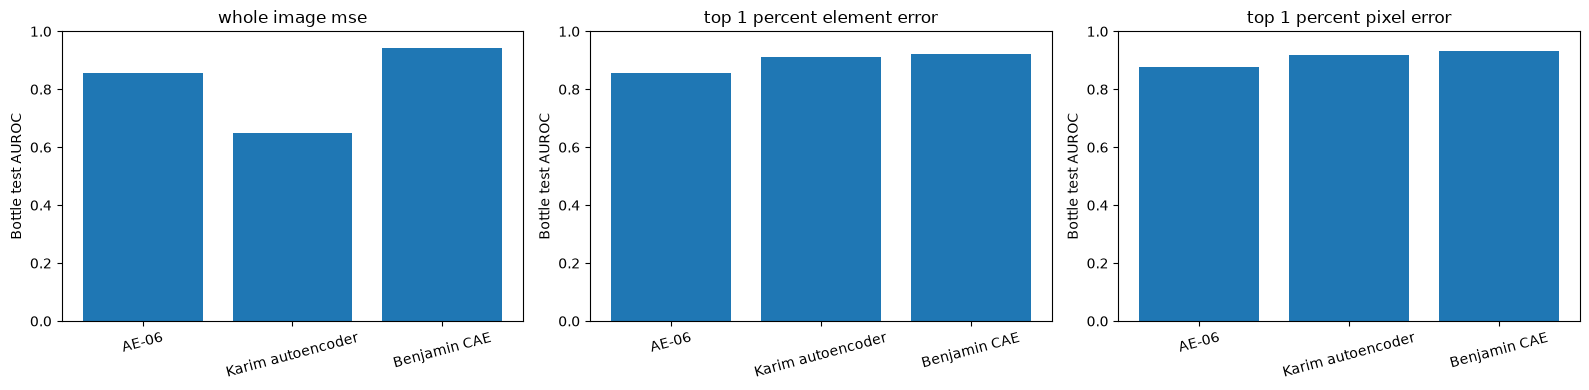

In [13]:
def score_loader(model, loader):
    rows = []
    model.eval()
    with torch.inference_mode():
        for images, labels, paths in loader:
            images = images.to(DEVICE, non_blocking=PIN_MEMORY)
            reconstructions = model(images)
            absolute_errors = (images - reconstructions).abs()
            mse_scores = absolute_errors.square().mean(dim=(1, 2, 3))
            flat_errors = absolute_errors.flatten(start_dim=1)
            k = max(1, int(flat_errors.shape[1] * 0.01))
            top1_scores = torch.topk(flat_errors, k, dim=1).values.mean(dim=1)
            pixel_errors = absolute_errors.mean(dim=1)
            flat_pixel_errors = pixel_errors.flatten(start_dim=1)
            pixel_k = max(1, int(flat_pixel_errors.shape[1] * 0.01))
            top1_pixel_scores = torch.topk(
                flat_pixel_errors, pixel_k, dim=1
            ).values.mean(dim=1)
            rows.extend({
                'label': int(label), 'path': path,
                'whole_image_mse': float(mse),
                'top_1_percent_element_error': float(top1),
                'top_1_percent_pixel_error': float(top1_pixel),
            } for label, path, mse, top1, top1_pixel in zip(
                labels, paths, mse_scores.cpu(), top1_scores.cpu(),
                top1_pixel_scores.cpu(),
            ))
    return pd.DataFrame(rows)

model_specs = {
    'AE-06': (ae06, ae06_validation_loader, ae06_test_loader),
    'Karim autoencoder': (karim, karim_validation_loader, karim_test_loader),
    'Benjamin CAE': (
        benjamin, benjamin_validation_loader, benjamin_test_loader,
    ),
}
score_names = [
    'whole_image_mse',
    'top_1_percent_element_error',
    'top_1_percent_pixel_error',
]
result_rows = []
scored_data = {}
for model_name, (model, validation_loader, test_loader) in model_specs.items():
    validation_results = score_loader(model, validation_loader)
    test_results = score_loader(model, test_loader)
    assert validation_results.label.eq(0).all()
    scored_data[model_name] = (validation_results, test_results)
    for score_name in score_names:
        threshold = np.percentile(
            validation_results[score_name], IMAGE_THRESHOLD_PERCENTILE
        )
        labels = test_results.label.to_numpy()
        predictions = (test_results[score_name] > threshold).astype(int)
        true_negatives = int(((labels == 0) & (predictions == 0)).sum())
        false_positives = int(((labels == 0) & (predictions == 1)).sum())
        true_positives = int(((labels == 1) & (predictions == 1)).sum())
        false_negatives = int(((labels == 1) & (predictions == 0)).sum())
        specificity = true_negatives / (true_negatives + false_positives)
        result_rows.append({
            'model': model_name,
            'score': score_name,
            'validation_threshold_95pct': threshold,
            'AUROC': roc_auc_score(labels, test_results[score_name]),
            'PR_AUC': average_precision_score(labels, test_results[score_name]),
            'precision': precision_score(labels, predictions, zero_division=0),
            'anomaly_recall': recall_score(labels, predictions, zero_division=0),
            'specificity': specificity,
            'F1': f1_score(labels, predictions, zero_division=0),
            'balanced_accuracy': balanced_accuracy_score(labels, predictions),
            'good_correct': true_negatives,
            'false_alarms': false_positives,
            'defects_detected': true_positives,
            'defects_missed': false_negatives,
        })
comparison = pd.DataFrame(result_rows)
display(comparison.round(6))

figure, axes = plt.subplots(1, 3, figsize=(16, 4))
for axis, score_name in zip(axes, score_names):
    subset = comparison.query('score == @score_name')
    axis.bar(subset.model, subset.AUROC)
    axis.set_ylim(0, 1)
    axis.set_ylabel('Bottle test AUROC')
    axis.set_title(score_name.replace('_', ' '))
    axis.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## False-negative defect sizes

This is a post-hoc diagnostic using the official test masks; the masks were not used to calculate anomaly scores or thresholds. It describes whether missed defects tend to be small, but it must not be used to tune the scoring rule and then claim an unbiased test result on the same images.

In [14]:
from PIL import Image

top_1_percent_pixels = max(1, int(IMAGE_SIZE**2 * 0.01))
false_negative_rows = []

for model_name, (_, test_results) in scored_data.items():
    for score_name in score_names:
        threshold = comparison.loc[
            (comparison.model == model_name) & (comparison.score == score_name),
            'validation_threshold_95pct',
        ].item()
        missed = test_results.loc[
            test_results.label.eq(1) & test_results[score_name].le(threshold)
        ]
        for row in missed.itertuples(index=False):
            image_path = Path(row.path)
            mask_path = (
                image_path.parents[2] / 'ground_truth' / image_path.parent.name
                / f'{image_path.stem}_mask.png'
            )
            mask = np.asarray(Image.open(mask_path).convert('L')) > 0
            original_defect_pixels = int(mask.sum())
            original_image_pixels = int(mask.size)
            defect_percentage = 100 * original_defect_pixels / original_image_pixels
            resized_equivalent_pixels = defect_percentage / 100 * IMAGE_SIZE**2
            false_negative_rows.append({
                'model': model_name,
                'score': score_name,
                'defect_type': image_path.parent.name,
                'image_id': image_path.stem,
                'anomaly_score': getattr(row, score_name),
                'threshold': threshold,
                'original_defect_pixels': original_defect_pixels,
                'original_image_pixels': original_image_pixels,
                'defect_percentage': defect_percentage,
                'equivalent_pixels_at_256': resized_equivalent_pixels,
                'equivalent_area_vs_top1': resized_equivalent_pixels / top_1_percent_pixels,
            })

false_negative_sizes = pd.DataFrame(false_negative_rows)
false_negative_summary = (
    false_negative_sizes.groupby(['model', 'score'])
    .agg(
        missed_defects=('image_id', 'size'),
        min_defect_pixels=('original_defect_pixels', 'min'),
        median_defect_pixels=('original_defect_pixels', 'median'),
        max_defect_pixels=('original_defect_pixels', 'max'),
        min_defect_percentage=('defect_percentage', 'min'),
        median_defect_percentage=('defect_percentage', 'median'),
        max_defect_percentage=('defect_percentage', 'max'),
        median_equivalent_pixels_at_256=('equivalent_pixels_at_256', 'median'),
    )
    .reset_index()
)

print(f'Top-1% spatial scoring uses {top_1_percent_pixels} of {IMAGE_SIZE**2:,} pixels.')
display(false_negative_summary.round(3))
display(
    false_negative_sizes.sort_values(
        ['model', 'score', 'defect_percentage']
    ).round({
        'anomaly_score': 6, 'threshold': 6, 'defect_percentage': 4,
        'equivalent_pixels_at_256': 1, 'equivalent_area_vs_top1': 3,
    })
)

Top-1% spatial scoring uses 655 of 65,536 pixels.


,model,score,missed_defects,min_defect_pixels,median_defect_pixels,max_defect_pixels,min_defect_percentage,median_defect_percentage,max_defect_percentage,median_equivalent_pixels_at_256
0,AE-06,top_1_percent_element_error,22,7166,59624.0,133876,0.885,7.361,16.528,4824.097
1,AE-06,top_1_percent_pixel_error,22,7166,73450.0,133876,0.885,9.068,16.528,5942.740
2,AE-06,whole_image_mse,16,7166,30396.0,133876,0.885,3.753,16.528,2459.299
3,Benjamin CAE,top_1_percent_element_error,10,12266,58414.0,133876,1.514,7.212,16.528,4726.197
4,Benjamin CAE,top_1_percent_pixel_error,11,12266,58708.0,133876,1.514,7.248,16.528,4749.985
5,Benjamin CAE,whole_image_mse,7,7166,33779.0,111640,0.885,4.170,13.783,2733.013
6,Karim autoencoder,top_1_percent_element_error,15,5429,58708.0,123943,0.670,7.248,15.302,4749.985
7,Karim autoencoder,top_1_percent_pixel_error,17,5429,58708.0,123943,0.670,7.248,15.302,4749.985
8,Karim autoencoder,whole_image_mse,31,5429,27013.0,133876,0.670,3.335,16.528,2185.585


,model,score,defect_type,image_id,anomaly_score,threshold,original_defect_pixels,original_image_pixels,defect_percentage,equivalent_pixels_at_256,equivalent_area_vs_top1
21,AE-06,top_1_percent_element_error,broken_small,000,0.159754,0.169280,7166,810000,0.8847,579.8,0.885
22,AE-06,top_1_percent_element_error,broken_small,005,0.133900,0.169280,12266,810000,1.5143,992.4,1.515
25,AE-06,top_1_percent_element_error,broken_small,015,0.157023,0.169280,13480,810000,1.6642,1090.6,1.665
28,AE-06,top_1_percent_element_error,contamination,002,0.160673,0.169280,14913,810000,1.8411,1206.6,1.842
23,AE-06,top_1_percent_element_error,broken_small,008,0.168312,0.169280,17311,810000,2.1372,1400.6,2.138
...,...,...,...,...,...,...,...,...,...,...,...
90,Karim autoencoder,whole_image_mse,contamination,020,0.779734,0.799833,121385,810000,14.9858,9821.1,14.994
88,Karim autoencoder,whole_image_mse,contamination,016,0.782212,0.799833,122515,810000,15.1253,9912.5,15.134
84,Karim autoencoder,whole_image_mse,contamination,012,0.794847,0.799833,122608,810000,15.1368,9920.0,15.145
60,Karim autoencoder,whole_image_mse,broken_large,002,0.786202,0.799833,125835,810000,15.5352,10181.1,15.544


## Autoencoder image-level results and interpretation

Among the three autoencoders, Benjamin's CAE produced the strongest image-level result under the shared seed-17 85/15 protocol. With whole-image MSE it achieved the highest autoencoder F1 (0.9256), AUROC (0.9421), and PR-AUC (0.9826). At its frozen normal-validation threshold it detected 56 of 63 defects, missed 7, and produced 2 false alarms among the 20 normal test images. This is the best autoencoder image-level configuration when the team's main F1 metric and defect recall are prioritized.

Benjamin's Top-1% element score achieved the highest balanced accuracy (0.8956), narrowly ahead of Benjamin whole-image MSE (0.8944). It reduced false alarms from two to one, but also reduced detected defects from 56 to 53, giving a lower F1 of 0.9060. Benjamin's spatial-pixel score followed the same trade-off and reached F1 0.8966. For Benjamin, whole-image MSE is therefore the strongest ranking and F1 choice, while Top-1% aggregation offers slightly greater specificity.

Karim's model depended strongly on local score aggregation. Whole-image MSE performed poorly (F1 0.6400 and AUROC 0.6500), whereas element-wise Top-1% scoring reached F1 0.8649 and AUROC 0.9127. Both Karim Top-1% variants produced zero false alarms; the element-wise version detected 48 defects and the spatial-pixel version detected 46. Karim's element-wise score is therefore the strongest evaluated operating point when avoiding every false alarm is more important than maximizing defect recall.

AE-06 achieved its best image-level F1 with whole-image MSE (0.8246), detecting 47 defects with 4 false alarms. Its Top-1% variants reduced false alarms to one but detected only 41 defects, lowering F1 to 0.7810. Spatial-pixel Top-1% improved its ranking AUROC to 0.8762 but did not improve the selected operating point.

The scoring interaction is method-specific. Benjamin and AE-06 benefit most from whole-image MSE at the selected thresholds, whereas Karim's useful evidence is concentrated in high-error locations and is diluted by whole-image averaging. This observation describes the complete methods and does not isolate whether Benjamin's advantage comes from masking, SSIM-MSE training, architecture, normalization, or their interaction.

### False negatives and training behavior

Benjamin's best autoencoder configuration missed 7 defects. Those misses were not exclusively tiny: their defect areas ranged from 0.885% to 13.783% of the original image, with a median of 4.170%. Defect size alone therefore does not explain failure; contrast, location, defect appearance, and plausible anomalous reconstruction are also likely relevant. This mask analysis remains post-hoc and was not used for model or threshold selection.

AE-06 selected epoch 199, while Karim and Benjamin selected epoch 200. Their normal-validation objectives continued improving through the end of the budget rather than showing clear late deterioration. Benjamin's validation SSIM-MSE loss fell from 0.7788 to 0.0277 as its learning rate decreased from `1e-3` to `3.125e-5`. Its training and validation losses are not a conventional overfitting pair because training reconstructs clean targets from masked inputs while validation reconstructs unmasked clean inputs.

## Pixel-level localization with AUPIMO

AUPIMO complements the image-level AUROC above: it evaluates whether a full spatial reconstruction-error map localizes the annotated defect. For each autoencoder, thresholds are indexed by the shared pixel-level false-positive rate measured on normal test images, and recall is integrated separately for every anomalous image over the strict default FPR range `[1e-5, 1e-4]`. The Top-1% aggregation and the image-level 95th-percentile threshold are not used here. The globally pooled ResNet baseline has no spatial anomaly map, so AUPIMO is not applicable to it.

The masks are resized with nearest-neighbor interpolation to preserve binary labels. AUPIMO is reported as an overall mean and by defect type; the per-image table is retained for analysis by defect size.

In [15]:
from anomalib.data import ImageBatch
from anomalib.metrics import AUPIMO
from PIL import Image

AUPIMO_FPR_BOUNDS = (1e-5, 1e-4)
AUPIMO_NUM_THRESHOLDS = 300_000

def ground_truth_mask(image_path):
    image_path = Path(image_path)
    if image_path.parent.name == 'good':
        return torch.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=torch.bool)
    mask_path = (
        image_path.parents[2] / 'ground_truth' / image_path.parent.name
        / f'{image_path.stem}_mask.png'
    )
    with Image.open(mask_path) as mask_image:
        resized_mask = mask_image.convert('L').resize(
            (IMAGE_SIZE, IMAGE_SIZE), Image.Resampling.NEAREST
        )
        mask_array = np.asarray(resized_mask).copy()
    return torch.from_numpy(mask_array > 0)


aupimo_rows = []
for model_name, (model, _, test_loader) in model_specs.items():
    metric = AUPIMO(
        num_thresholds=AUPIMO_NUM_THRESHOLDS,
        fpr_bounds=AUPIMO_FPR_BOUNDS,
        return_average=False,
    )
    ordered_paths = []
    model.eval()
    with torch.inference_mode():
        for images, _, paths in test_loader:
            device_images = images.to(DEVICE, non_blocking=PIN_MEMORY)
            reconstructions = model(device_images)
            anomaly_maps = (
                device_images - reconstructions
            ).abs().mean(dim=1).cpu()
            masks = torch.stack([ground_truth_mask(path) for path in paths])
            metric.update(ImageBatch(
                image=images.cpu(), anomaly_map=anomaly_maps, gt_mask=masks
            ))
            ordered_paths.extend(paths)

    _, aupimo_result = metric.compute()
    per_image_aupimo = aupimo_result.aupimos.cpu().numpy()
    assert len(per_image_aupimo) == len(ordered_paths)
    for path, score in zip(ordered_paths, per_image_aupimo, strict=True):
        if np.isnan(score):  # normal images do not receive an AUPIMO score
            continue
        image_path = Path(path)
        aupimo_rows.append({
            'model': model_name,
            'defect_type': image_path.parent.name,
            'image_id': image_path.stem,
            'AUPIMO': float(score),
        })

aupimo_per_image = pd.DataFrame(aupimo_rows)
aupimo_overall = (
    aupimo_per_image.groupby('model', as_index=False)
    .agg(AUPIMO=('AUPIMO', 'mean'), image_count=('AUPIMO', 'size'))
)
aupimo_by_defect_type = (
    aupimo_per_image.groupby(['model', 'defect_type'], as_index=False)
    .agg(
        mean_AUPIMO=('AUPIMO', 'mean'),
        median_AUPIMO=('AUPIMO', 'median'),
        image_count=('AUPIMO', 'size'),
    )
)

display(aupimo_overall.round(4))
display(aupimo_by_defect_type.round(4))
display(aupimo_per_image.sort_values(['model', 'AUPIMO']).round(4))

Metric `AUPIMO` will save all targets and predictions in buffer. For large datasets this may lead to large memory footprint.
Metric `AUPIMO` will save all targets and predictions in buffer. For large datasets this may lead to large memory footprint.
Metric `AUPIMO` will save all targets and predictions in buffer. For large datasets this may lead to large memory footprint.


,model,AUPIMO,image_count
0,AE-06,0.0300,63
1,Benjamin CAE,0.0328,63
2,Karim autoencoder,0.0486,63


,model,defect_type,mean_AUPIMO,median_AUPIMO,image_count
0,AE-06,broken_large,0.0135,0.0074,20
1,AE-06,broken_small,0.0432,0.0410,22
2,AE-06,contamination,0.0318,0.0000,21
3,Benjamin CAE,broken_large,0.0129,0.0086,20
4,Benjamin CAE,broken_small,0.0389,0.0301,22
5,Benjamin CAE,contamination,0.0455,0.0000,21
6,Karim autoencoder,broken_large,0.0242,0.0155,20
7,Karim autoencoder,broken_small,0.0814,0.0660,22
8,Karim autoencoder,contamination,0.0375,0.0000,21


,model,defect_type,image_id,AUPIMO
42,AE-06,contamination,000,0.0000
43,AE-06,contamination,001,0.0000
44,AE-06,contamination,002,0.0000
45,AE-06,contamination,003,0.0000
48,AE-06,contamination,006,0.0000
...,...,...,...,...
84,Karim autoencoder,broken_small,001,0.1402
101,Karim autoencoder,broken_small,018,0.1512
100,Karim autoencoder,broken_small,017,0.1963
87,Karim autoencoder,broken_small,004,0.2744


## Pixel-level F1

Pixel-level F1 requires a binary anomaly mask, so each autoencoder receives its own pixel-error threshold calculated only from its normal-validation error maps. The common rule is the 99th percentile of all normal-validation pixel errors. This is deliberately separate from the 95th-percentile image-score threshold: applying the 95th percentile to pixels would label approximately 5% (about 3,277 pixels) of every normal 256 x 256 image as anomalous by construction. A 99th-percentile pixel threshold still uses the same leakage-free validation procedure while targeting a lower pixel false-positive rate. The globally pooled ResNet baseline cannot be evaluated with pixel F1 because it produces no pixel predictions.

Global pixel precision, recall, and F1 aggregate the confusion counts over every pixel in the official test set and provide the primary segmentation result. Mean anomalous-image F1 gives every defective image equal weight and is retained as a secondary diagnostic. Test masks are used only after the validation thresholds have been frozen.

In [16]:
pixel_metric_rows = []

for model_name, (model, validation_loader, test_loader) in model_specs.items():
    validation_pixel_errors = []
    model.eval()
    with torch.inference_mode():
        for images, _, _ in validation_loader:
            images = images.to(DEVICE, non_blocking=PIN_MEMORY)
            reconstructions = model(images)
            validation_pixel_errors.append(
                (images - reconstructions).abs().mean(dim=1).cpu().flatten()
            )
    pixel_threshold = np.percentile(
        torch.cat(validation_pixel_errors).numpy(), PIXEL_THRESHOLD_PERCENTILE
    )

    global_predictions = []
    global_targets = []
    anomalous_image_f1 = []
    with torch.inference_mode():
        for images, labels, paths in test_loader:
            device_images = images.to(DEVICE, non_blocking=PIN_MEMORY)
            anomaly_maps = (
                device_images - model(device_images)
            ).abs().mean(dim=1).cpu()
            predictions = anomaly_maps > pixel_threshold
            targets = torch.stack([ground_truth_mask(path) for path in paths])
            global_predictions.append(predictions.flatten())
            global_targets.append(targets.flatten())
            for prediction, target, label in zip(
                predictions, targets, labels, strict=True
            ):
                if int(label) == 1:
                    anomalous_image_f1.append(f1_score(
                        target.flatten().numpy(), prediction.flatten().numpy(),
                        zero_division=0,
                    ))

    targets = torch.cat(global_targets).numpy()
    predictions = torch.cat(global_predictions).numpy()
    pixel_metric_rows.append({
        'model': model_name,
        'validation_pixel_threshold_99pct': pixel_threshold,
        'pixel_precision_global': precision_score(
            targets, predictions, zero_division=0
        ),
        'pixel_recall_global': recall_score(
            targets, predictions, zero_division=0
        ),
        'pixel_F1_global': f1_score(targets, predictions, zero_division=0),
        'mean_anomalous_image_pixel_F1': np.mean(anomalous_image_f1),
    })

pixel_comparison = pd.DataFrame(pixel_metric_rows)
display(pixel_comparison.round(6))

,model,validation_pixel_threshold_99pct,pixel_precision_global,pixel_recall_global,pixel_F1_global,mean_anomalous_image_pixel_F1
0,AE-06,0.088295,0.311124,0.090202,0.139856,0.172749
1,Karim autoencoder,1.439305,0.140136,0.028389,0.047213,0.082023
2,Benjamin CAE,0.055566,0.470325,0.186126,0.266706,0.294570


### Pixel-localization interpretation

Among the three autoencoders that produce spatial anomaly maps, Benjamin achieved the strongest result on the team's main pixel-level metric. Its global pixel F1 was 0.2667, compared with 0.1399 for AE-06 and 0.0472 for Karim. Benjamin combined the highest pixel precision (0.4703) and recall (0.1861), and its mean per-anomalous-image pixel F1 (0.2946) was also highest. The ordering is therefore consistent for both the global aggregation and the equal-image-weight diagnostic.

The absolute pixel F1 values remain low, particularly because pixel recall is low for every autoencoder: 0.1861 for Benjamin, 0.0902 for AE-06, and 0.0284 for Karim. At the validation-derived 99th-percentile pixel thresholds, all three autoencoders identify only a minority of annotated defective pixels. Benjamin is the strongest of the three for this metric, but the result does not yet support reliable defect segmentation.

AUPIMO gives a different ordering because it integrates localization recall over a strict low-FPR range rather than evaluating the single 99th-percentile operating point. Karim achieved the highest mean AUPIMO (0.0486), followed by Benjamin (0.0328) and AE-06 (0.0300). Karim was especially strong on `broken_small` defects, with mean AUPIMO 0.0814 versus 0.0432 for AE-06 and 0.0389 for Benjamin. Benjamin was strongest on `contamination`, with mean AUPIMO 0.0455.

These findings are not contradictory. Benjamin provides the best binary masks at the chosen validation-derived threshold, whereas Karim's error maps offer better localization behavior across AUPIMO's much stricter range of pixel false-positive rates. Image-level detection, thresholded pixel segmentation, and low-FPR localization are distinct outcomes and should be reported separately. All three AUPIMO values are low in absolute terms, reinforcing the conclusion that localization remains the main weakness.

## Autoencoder image-level ROC curves

These curves cover the three autoencoders and their reconstruction-based score variants. Each curve shows the image-level true-positive rate against the false-positive rate across every possible anomaly-score threshold. The `X` markers show the operating points produced by the selected 95th-percentile normal-validation thresholds used in the results table. The dashed diagonal represents random ranking. The ResNet baseline is evaluated separately below and included in the final combined metric table.

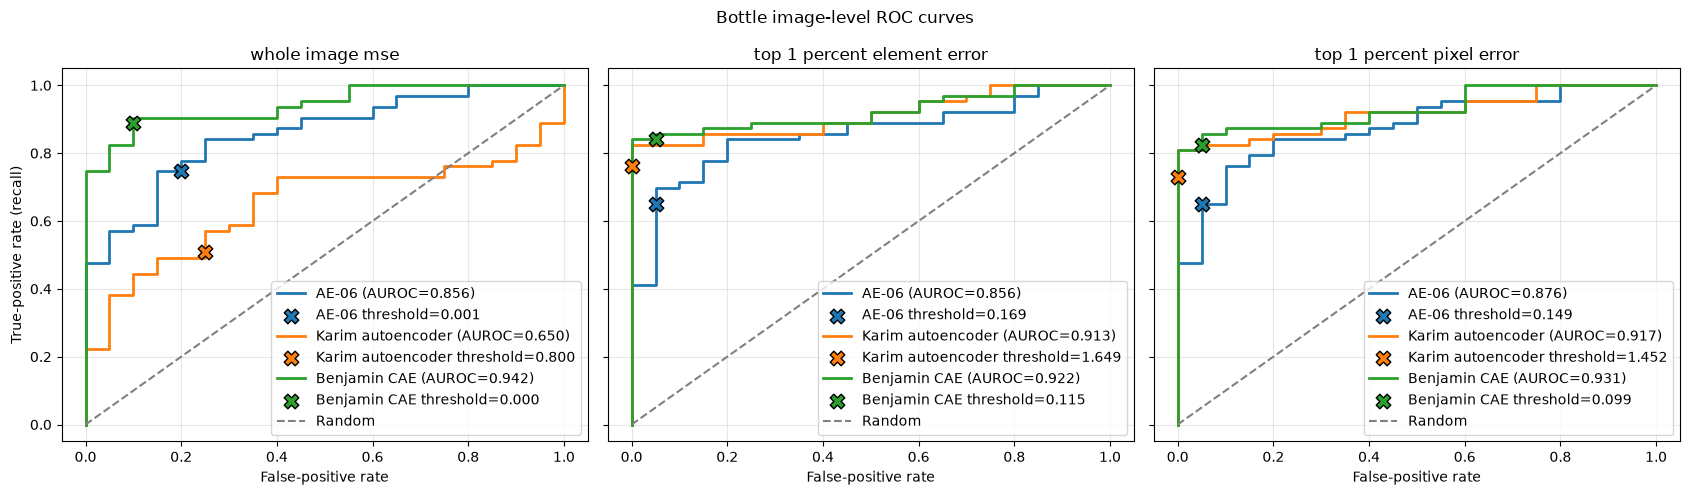

In [17]:
from sklearn.metrics import roc_curve

figure, axes = plt.subplots(1, len(score_names), figsize=(17, 5), sharex=True, sharey=True)
model_colors = {
    'AE-06': 'tab:blue', 'Karim autoencoder': 'tab:orange',
    'Benjamin CAE': 'tab:green',
}

for axis, score_name in zip(axes, score_names, strict=True):
    for model_name, (_, test_results) in scored_data.items():
        false_positive_rate, true_positive_rate, _ = roc_curve(
            test_results.label, test_results[score_name]
        )
        auc = comparison.loc[
            (comparison.model == model_name) & (comparison.score == score_name),
            'AUROC',
        ].item()
        selected_threshold = comparison.loc[
            (comparison.model == model_name) & (comparison.score == score_name),
            'validation_threshold_95pct',
        ].item()
        labels = test_results.label.to_numpy()
        selected_predictions = test_results[score_name].to_numpy() > selected_threshold
        selected_fpr = ((labels == 0) & selected_predictions).sum() / (labels == 0).sum()
        selected_tpr = ((labels == 1) & selected_predictions).sum() / (labels == 1).sum()
        axis.plot(
            false_positive_rate, true_positive_rate, linewidth=2,
            color=model_colors[model_name],
            label=f'{model_name} (AUROC={auc:.3f})',
        )
        axis.scatter(
            selected_fpr, selected_tpr, marker='X', s=110,
            color=model_colors[model_name], edgecolor='black', zorder=3,
            label=f'{model_name} threshold={selected_threshold:.3f}',
        )
    axis.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
    axis.set_title(score_name.replace('_', ' '))
    axis.set_xlabel('False-positive rate')
    axis.grid(alpha=0.3)
    axis.legend(loc='lower right')

axes[0].set_ylabel('True-positive rate (recall)')
figure.suptitle('Bottle image-level ROC curves')
plt.tight_layout()
plt.show()

## Autoencoder findings and limitations

Within the three-autoencoder comparison, Benjamin's masked SSIM-MSE CAE produced the strongest results on both team-selected main metrics. Benjamin with whole-image MSE achieved the best autoencoder image-level F1 (0.9256), AUROC (0.9421), and PR-AUC (0.9826). Benjamin also achieved the best global pixel F1 (0.2667) at the validation-derived 99th-percentile pixel threshold. The separate ResNet section below extends the image-level comparison but not the pixel-level comparison.

The secondary autoencoder metrics reveal important qualifications. Karim's element-wise Top-1% score was the strongest zero-false-alarm autoencoder image configuration, with F1 0.8649, and Karim achieved the highest AUPIMO (0.0486). Benjamin therefore leads autoencoder image classification and thresholded pixel F1, while Karim's anomaly maps perform best across AUPIMO's strict low-FPR range. AE-06 did not lead a main metric, but remained a useful original autoencoder baseline against which the two teammate methods improved.

This experiment compares complete methods rather than isolated architectures. It cannot determine whether Benjamin's advantage is caused by masking, SSIM-MSE training, ELU and BatchNorm, AdamW, bottleneck design, or their interaction. Benjamin's result applies specifically to the close PyTorch reproduction under the common 256 x 256 whole-image protocol, not to his original 64-pixel crop pipeline. Raw losses and numerical thresholds must not be compared directly across methods because their preprocessing and training objectives differ.

Localization remains weak despite Benjamin's relative advantage: its global pixel recall is only 0.1861 and its pixel F1 is 0.2667. The next research step should focus on improving spatial anomaly maps rather than treating the current reconstruction errors as production-ready segmentation.

Finally, the Bottle test set contains only 83 images, including just 20 normal images, so one additional image-level false alarm changes specificity by 0.05. The reported ordering is evidence for this Bottle experiment, not a general ranking across MVTec AD. It should ideally be checked with paired uncertainty estimates, repeated training runs, or additional product categories.

## Frozen ResNet-18 + 5-NN baseline

Notebook 02 is not directly comparable as written: it uses a seed-17 80/20 reference/validation split, whereas this notebook uses the shared seed-17 85/15 split. The baseline below therefore re-runs the same method with this notebook's 177 normal reference images, 32 normal validation images, official Bottle test set, 95th-percentile validation threshold, and image-level metric definitions.

The input remains 224 x 224 with ImageNet normalization because that is the pretrained ResNet-18 representation used by the baseline. This is a method-specific preprocessing choice, just as the autoencoders retain method-specific normalization and output activations. The comparison is between complete anomaly-detection methods, not an architecture-only ablation.

The baseline is evaluated with every agreed image-level metric: F1, precision, anomaly recall, specificity, balanced accuracy, AUROC, PR-AUC, and the four confusion counts. Ordinary accuracy remains omitted consistently for all methods because the test set is imbalanced. ResNet's global embedding provides no spatial anomaly map, so pixel F1 and AUPIMO are explicitly not applicable rather than silently treated as zero.

In [18]:
import torch.nn.functional as F
from sklearn.neighbors import NearestNeighbors
from torchvision.models import ResNet18_Weights, resnet18

RESNET_IMAGE_SIZE = 224
RESNET_K = 5

resnet_weights = ResNet18_Weights.DEFAULT
resnet_normalization = resnet_weights.transforms()
resnet_transform = transforms.Compose([
    transforms.Resize((RESNET_IMAGE_SIZE, RESNET_IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=resnet_normalization.mean, std=resnet_normalization.std,
    ),
])

resnet_reference_dataset = MVTecImageDataset(train_frame, resnet_transform)
resnet_validation_dataset = MVTecImageDataset(
    validation_frame, resnet_transform
)
resnet_test_dataset = MVTecImageDataset(test_frame, resnet_transform)
resnet_loader_options = dict(
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
resnet_reference_loader = DataLoader(
    resnet_reference_dataset, **resnet_loader_options
)
resnet_validation_loader = DataLoader(
    resnet_validation_dataset, **resnet_loader_options
)
resnet_test_loader = DataLoader(
    resnet_test_dataset, **resnet_loader_options
)

resnet_feature_extractor = resnet18(weights=resnet_weights)
resnet_feature_extractor.fc = nn.Identity()
resnet_feature_extractor.requires_grad_(False)
resnet_feature_extractor = resnet_feature_extractor.to(DEVICE).eval()

assert len(resnet_reference_dataset) == 177
assert len(resnet_validation_dataset) == 32
assert len(resnet_test_dataset) == len(test_frame)


In [19]:
def extract_resnet_embeddings(model, loader):
    embedding_batches = []
    label_batches = []
    paths = []
    model.eval()
    with torch.inference_mode():
        for images, labels, batch_paths in loader:
            embeddings = model(
                images.to(DEVICE, non_blocking=PIN_MEMORY)
            )
            embedding_batches.append(embeddings.cpu())
            label_batches.append(labels.cpu())
            paths.extend(batch_paths)
    embeddings = F.normalize(torch.cat(embedding_batches), p=2, dim=1)
    labels = torch.cat(label_batches).numpy().astype(int)
    return embeddings.numpy(), labels, paths


reference_embeddings, reference_labels, reference_paths = (
    extract_resnet_embeddings(
        resnet_feature_extractor, resnet_reference_loader
    )
)
validation_embeddings, validation_labels, validation_paths = (
    extract_resnet_embeddings(
        resnet_feature_extractor, resnet_validation_loader
    )
)
test_embeddings, resnet_test_labels, resnet_test_paths = (
    extract_resnet_embeddings(resnet_feature_extractor, resnet_test_loader)
)

assert not reference_labels.any()
assert not validation_labels.any()
assert resnet_test_paths == test_frame.path.tolist()
assert np.array_equal(
    resnet_test_labels, test_frame.is_anomaly.to_numpy(dtype=int)
)

resnet_neighbor_model = NearestNeighbors(
    n_neighbors=RESNET_K, metric='euclidean'
)
resnet_neighbor_model.fit(reference_embeddings)
validation_scores = resnet_neighbor_model.kneighbors(
    validation_embeddings, return_distance=True
)[0].mean(axis=1)
resnet_test_scores = resnet_neighbor_model.kneighbors(
    test_embeddings, return_distance=True
)[0].mean(axis=1)
resnet_threshold = np.percentile(
    validation_scores, IMAGE_THRESHOLD_PERCENTILE
)
resnet_predictions = (resnet_test_scores > resnet_threshold).astype(int)


In [20]:
labels = resnet_test_labels
true_negatives = int(((labels == 0) & (resnet_predictions == 0)).sum())
false_positives = int(((labels == 0) & (resnet_predictions == 1)).sum())
true_positives = int(((labels == 1) & (resnet_predictions == 1)).sum())
false_negatives = int(((labels == 1) & (resnet_predictions == 0)).sum())
specificity = true_negatives / (true_negatives + false_positives)

resnet_baseline_row = pd.DataFrame([{
    'model': 'Frozen ResNet-18 + 5-NN',
    'score': 'mean_5nn_distance',
    'validation_threshold_95pct': resnet_threshold,
    'AUROC': roc_auc_score(labels, resnet_test_scores),
    'PR_AUC': average_precision_score(labels, resnet_test_scores),
    'precision': precision_score(
        labels, resnet_predictions, zero_division=0
    ),
    'anomaly_recall': recall_score(
        labels, resnet_predictions, zero_division=0
    ),
    'specificity': specificity,
    'F1': f1_score(labels, resnet_predictions, zero_division=0),
    'balanced_accuracy': balanced_accuracy_score(
        labels, resnet_predictions
    ),
    'good_correct': true_negatives,
    'false_alarms': false_positives,
    'defects_detected': true_positives,
    'defects_missed': false_negatives,
}])

comparison_with_resnet = pd.concat(
    [comparison, resnet_baseline_row], ignore_index=True
)
agreed_image_metric_columns = [
    'AUROC', 'PR_AUC', 'precision', 'anomaly_recall', 'specificity',
    'F1', 'balanced_accuracy', 'good_correct', 'false_alarms',
    'defects_detected', 'defects_missed',
]
missing_baseline_metrics = [
    metric for metric in agreed_image_metric_columns
    if metric not in resnet_baseline_row.columns
]
assert not missing_baseline_metrics, (
    f'Missing agreed baseline metrics: {missing_baseline_metrics}'
)
assert resnet_baseline_row[agreed_image_metric_columns].notna().all().all()
assert set(comparison.columns) == set(resnet_baseline_row.columns)

display(resnet_baseline_row.round(6))
display(
    comparison_with_resnet.sort_values(
        ['AUROC', 'F1'], ascending=False
    ).round(6)
)

,model,score,validation_threshold_95pct,AUROC,PR_AUC,precision,anomaly_recall,specificity,F1,balanced_accuracy,good_correct,false_alarms,defects_detected,defects_missed
0,Frozen ResNet-18 + 5-NN,mean_5nn_distance,0.156897,0.988095,0.996015,0.983333,0.936508,0.95,0.95935,0.943254,19,1,59,4


,model,score,validation_threshold_95pct,AUROC,PR_AUC,precision,anomaly_recall,specificity,F1,balanced_accuracy,good_correct,false_alarms,defects_detected,defects_missed
9,Frozen ResNet-18 + 5-NN,mean_5nn_distance,0.156897,0.988095,0.996015,0.983333,0.936508,0.95,0.959350,0.943254,19,1,59,4
6,Benjamin CAE,whole_image_mse,0.000409,0.942063,0.982590,0.965517,0.888889,0.90,0.925620,0.894444,18,2,56,7
8,Benjamin CAE,top_1_percent_pixel_error,0.099324,0.930952,0.980096,0.981132,0.825397,0.95,0.896552,0.887698,19,1,52,11
7,Benjamin CAE,top_1_percent_element_error,0.115188,0.922222,0.978298,0.981481,0.841270,0.95,0.905983,0.895635,19,1,53,10
5,Karim autoencoder,top_1_percent_pixel_error,1.451548,0.917460,0.976379,1.000000,0.730159,1.00,0.844037,0.865079,20,0,46,17
4,Karim autoencoder,top_1_percent_element_error,1.649183,0.912698,0.975175,1.000000,0.761905,1.00,0.864865,0.880952,20,0,48,15
2,AE-06,top_1_percent_pixel_error,0.149157,0.876190,0.960026,0.976190,0.650794,0.95,0.780952,0.800397,19,1,41,22
0,AE-06,whole_image_mse,0.000830,0.856349,0.952182,0.921569,0.746032,0.80,0.824561,0.773016,16,4,47,16
1,AE-06,top_1_percent_element_error,0.169280,0.856349,0.954061,0.976190,0.650794,0.95,0.780952,0.800397,19,1,41,22
3,Karim autoencoder,whole_image_mse,0.799833,0.650000,0.881315,0.864865,0.507937,0.75,0.640000,0.628968,15,5,32,31


### Overall conclusion including the ResNet baseline

Under the shared 85/15 protocol, the frozen ResNet-18 + 5-NN baseline achieves AUROC 0.9881, PR-AUC 0.9960, F1 0.9594, and balanced accuracy 0.9433. At its normal-validation threshold it detects 59 of 63 defects and raises one false alarm among 20 normal test images. It therefore outperforms the evaluated autoencoders on the reported image-level ranking and threshold metrics; Benjamin's whole-image MSE remains the strongest autoencoder configuration (F1 0.9256, AUROC 0.9421).

This result strengthens the baseline rather than invalidating the localization analysis. The global ResNet embedding does not yield a spatial anomaly map, so the autoencoder pixel-F1 and AUPIMO results answer a separate question and have no ResNet value to compare against. The evidence supports keeping ResNet-18 + 5-NN as the image-level baseline while continuing autoencoder work when defect localization or learning product-specific normal structure is the research goal.